# Allen–Cahn (φ⁴) in d=1 — a polynomial spatial vertex

**Showcases:** the spatial MSR-JD machinery on the simplest interacting field — a φ⁴ (polynomial) vertex. The pipeline builds heat-kernel propagators, reduces the loop integral via Symanzik polynomials over causal time-chambers, and inverse-Fourier-transforms back to real space. Here it is run to **1-loop**.

$$\partial_t\phi = D\,\partial_x^2\phi - \mu\phi - \lambda\phi^3 + \eta,\qquad \langle\eta\eta\rangle = 2T\,\delta\,\delta.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
THEORY = 'allen_cahn_1d_subcritical_infinite'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)

────────────────────────────────────────────────────────────────────────
  1D stochastic Allen-Cahn (subcritical, infinite domain)
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : phi (x∈ℝ^1) — order parameter
Response fields: phit
Parameters     :
    mu = 1.0  (positive)
    D = 1.0  (positive)
    lam = 0.1  (positive)
    T = 1.0  (positive)
Mean-field saddle (solved by the pipeline): phistar
Governing eqn  : (Dt + mu - D*Laplacian)*phi = -lam*phi^3
Suggested run  : k=2, max_ell=0

1D stochastic Allen-Cahn (subcritical, infinite domain) — spatial v1
test theory.

The first spatial field theory in Daedalus.  Off-critical (μ > 0),
infinite domain, stationary initial condition.  Free part is an
Ornstein-Uhlenbeck-in-time × heat-kernel-in-space propagator; the
λφ³ vertex drives the 1-loop self-energy correction.

    (∂_t + μ - D ∇²) φ  =  -λ φ³  +  η,
    ⟨η(x,t) η(x',t

"────────────────────────────────────────────────────────────────────────\n  1D stochastic Allen-Cahn (subcritical, infinite domain)\n────────────────────────────────────────────────────────────────────────\nDomain         : spatial PDE · d=1 · boundary=infinite · initial=stationary\nFields         : phi (x∈ℝ^1) — order parameter\nResponse fields: phit\nParameters     :\n    mu = 1.0  (positive)\n    D = 1.0  (positive)\n    lam = 0.1  (positive)\n    T = 1.0  (positive)\nMean-field saddle (solved by the pipeline): phistar\nGoverning eqn  : (Dt + mu - D*Laplacian)*phi = -lam*phi^3\nSuggested run  : k=2, max_ell=0\n\n1D stochastic Allen-Cahn (subcritical, infinite domain) — spatial v1\ntest theory.\n\nThe first spatial field theory in Daedalus.  Off-critical (μ > 0),\ninfinite domain, stationary initial condition.  Free part is an\nOrnstein-Uhlenbeck-in-time × heat-kernel-in-space propagator; the\nλφ³ vertex drives the 1-loop self-energy correction.\n\n    (∂_t + μ - D ∇²) φ  =  -λ φ³  

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). The plot is the **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=1,                 # two-point ⟨φφ⟩, tree + 1-loop
    external_fields=[('dphi', 1), ('dphi', 1)],
    spatial_grid=(0.0, 6.0, 25),    # equal-time C(x) on x ∈ [0, 6]
    tau_max=0.0,
)

theory : '1D stochastic Allen-Cahn (subcritical, infinite domain)'
k      : 2    max_ell : 1
fields : ['dphi']   spatial_dim : 1
diagrams (live): 1


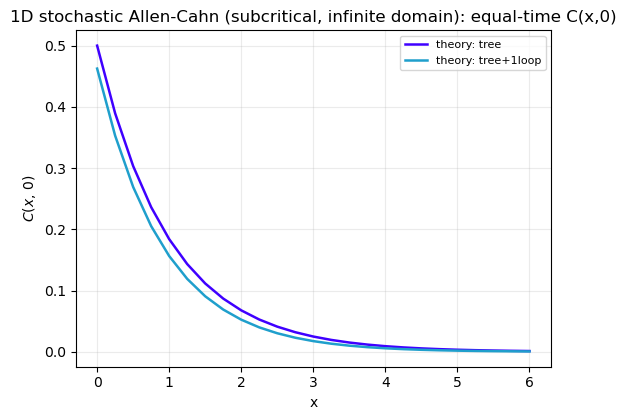

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct numerical integration of the SPDE — written from scratch, with no reference to the diagrammatics. Overlaying it on the pipeline curve is the validation.

theory C(0) = 0.4625   sim C(0) = 0.4689   (sim mean = 0.008)


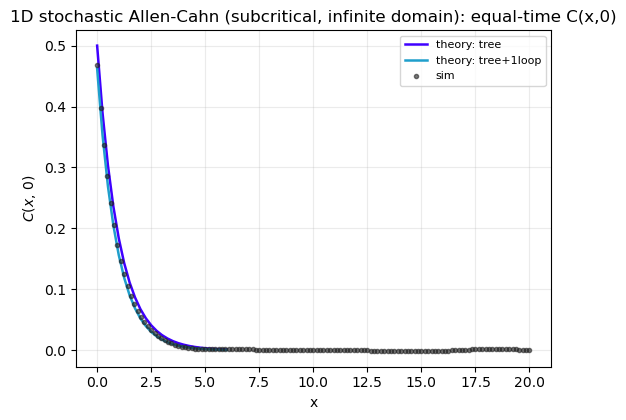

In [5]:
# Independent SPDE simulation (direct ETD1 integration) — NOT the
# pipeline.  Same physical parameters as the theory (read from the model).
from models.spatial_field_1d_sim import simulate, equal_time_correlator
fp = dd.parameters_from_model(model)
snaps, x_grid, meta = simulate(L=40.0, N=256, mu=fp['mu'], D=fp['D'], T=fp['T'],
                               lam=fp['lam'],
                               n_steps=120000, burn_in=20000, record_every=20, seed=1)
mean = float(np.mean(snaps))      # ⟨φ⟩: ≈0 if symmetric, the excess velocity for KPZ
Cx = equal_time_correlator(snaps) - mean**2   # CONNECTED (the pipeline gives connected)
half = len(x_grid) // 2 + 1
sim = {'x': x_grid[:half], 'C': Cx[:half]}
mid = res['C_tau_x'].shape[0] // 2
print('theory C(0) = %.4f   sim C(0) = %.4f   (sim mean = %.3f)'
      % (np.real(res['C_tau_x'])[mid][0], sim['C'][0], mean))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

The 1-loop φ⁴ self-energy lifts the equal-time variance C(0) above the free (tree) value; the direct SPDE simulation confirms it. This is the spatial pipeline's reference case — every other spatial example swaps only the vertex.